In [1]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))


Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”


In [2]:
# path to tsv with LM coefficients
lm_results_dir <- file.path("./results/")
lm_file <- file.path(lm_results_dir, "localhost220512140003_KK22-05-198_linear_model_dose_count.tsv")

# save path for figure
lm_fig_dir <- file.path("./figures")
if (!dir.exists(lm_fig_dir)) {
    dir.create(lm_fig_dir, recursive = TRUE)
}
lm_fig <- file.path(lm_fig_dir, "linear_model_cp_features_heart3_dose_count.png")

# Load and process linear model data
lm_df <- readr::read_tsv(
    lm_file,
    col_types = readr::cols(.default = "d", Feature = "c")
)

print(dim(lm_df))
head(lm_df)


[1] 2003    5


Feature,r2_score,cell_count_coef,dose_coef,intercept
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Cytoplasm_AreaShape_Area,0.0198711939,-1.537836e-04,0.052837962,0.041401293
Cytoplasm_AreaShape_BoundingBoxArea,0.0025772418,-3.862030e-04,-0.007034795,0.219846568
Cytoplasm_AreaShape_BoundingBoxMaximum_X,0.0003289094,-8.923184e-05,0.006345945,0.035014947
Cytoplasm_AreaShape_BoundingBoxMaximum_Y,0.0004832643,-2.385685e-05,-0.007611755,0.029064990
Cytoplasm_AreaShape_BoundingBoxMinimum_X,0.0002326140,-3.597379e-05,0.005551274,0.004014322
Cytoplasm_AreaShape_BoundingBoxMinimum_Y,0.0005100626,4.085438e-05,-0.008276532,-0.002193142


In [3]:
# Arrange by absolute value coefficient
# Split out components of feature name for visualization
lm_df <- lm_df %>%
    dplyr::arrange(desc(abs(dose_coef))) %>%
    tidyr::separate(
        Feature,
        into = c(
            "compartment",
            "feature_group",
            "measurement",
            "channel",
            "parameter1",
            "parameter2",
            "parameter3"
        ),
        sep = "_",
        remove = FALSE
    ) %>%
    dplyr::mutate(channel_cleaned = channel)

lm_df$channel_cleaned <- dplyr::recode(lm_df$channel_cleaned,
    "Hoechst" = "Nucleus",
    "ER" = "ER",
    "Actin" = "Actin",
    "Mitochondria" = "Mito",
    "PM" = "PM",
    .default = "other",
    .missing = "other"
)

print(dim(lm_df))
head(lm_df, 3)


Warning message:
“Expected 7 pieces. Missing pieces filled with `NA` in 1223 rows [1, 2, 3, 4, 5,
6, 7, 9, 13, 24, 26, 35, 49, 50, 51, 53, 54, 57, 58, 61, ...].”


[1] 2003   13


Feature,compartment,feature_group,measurement,channel,parameter1,parameter2,parameter3,r2_score,cell_count_coef,dose_coef,intercept,channel_cleaned
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Cytoplasm_Correlation_Costes_ER_Actin,Cytoplasm,Correlation,Costes,ER,Actin,NA,NA,0.2762606,0.001846830,0.1873934,-1.639035,ER
Cells_Correlation_Costes_ER_Actin,Cells,Correlation,Costes,ER,Actin,NA,NA,0.2776999,0.001747548,0.1870298,-1.578927,ER
Nuclei_Correlation_Costes_Actin_ER,Nuclei,Correlation,Costes,Actin,ER,NA,NA,0.2458048,0.001939352,0.1847509,-1.664424,Actin


In [4]:
# Drop rows with specific feature_group values
lm_df <- lm_df %>%
    dplyr::filter(!feature_group %in% c("Neighbors", "Location", "Parent", "Children", "Number"))

print(dim(lm_df))
head(lm_df, 3)


[1] 1890   13


Feature,compartment,feature_group,measurement,channel,parameter1,parameter2,parameter3,r2_score,cell_count_coef,dose_coef,intercept,channel_cleaned
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Cytoplasm_Correlation_Costes_ER_Actin,Cytoplasm,Correlation,Costes,ER,Actin,NA,NA,0.2762606,0.001846830,0.1873934,-1.639035,ER
Cells_Correlation_Costes_ER_Actin,Cells,Correlation,Costes,ER,Actin,NA,NA,0.2776999,0.001747548,0.1870298,-1.578927,ER
Nuclei_Correlation_Costes_Actin_ER,Nuclei,Correlation,Costes,Actin,ER,NA,NA,0.2458048,0.001939352,0.1847509,-1.664424,Actin


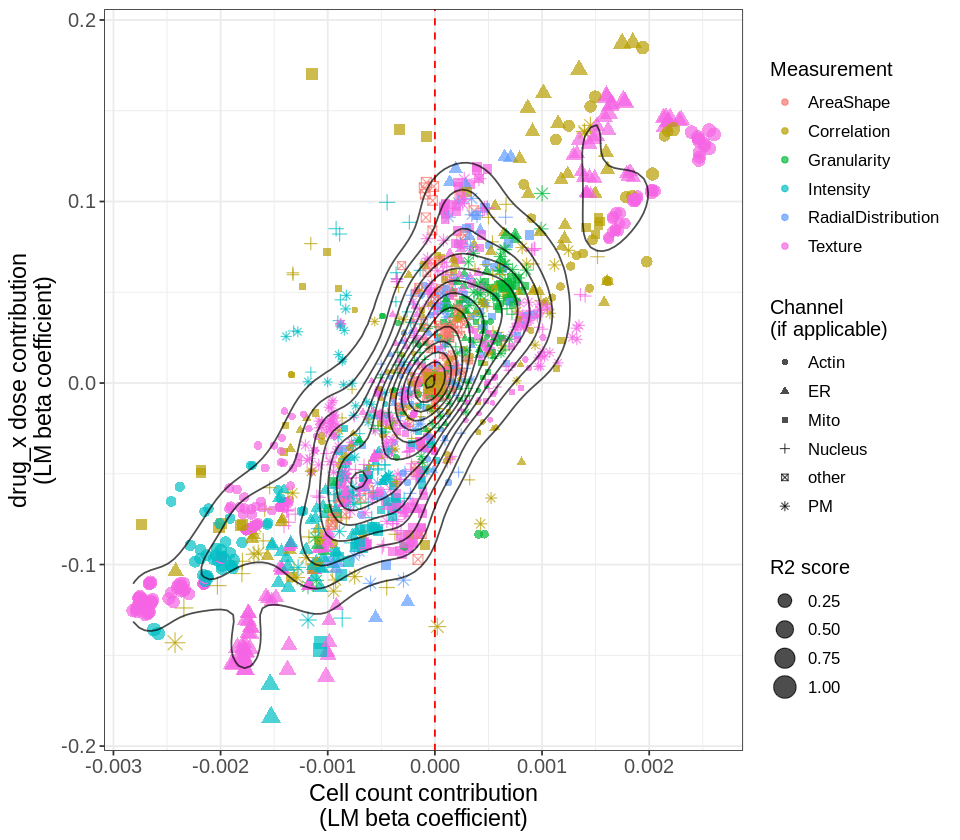

In [ ]:
width <- 8
height <- 7
options(repr.plot.width = width, repr.plot.height = height)

# Plot the linear model coefficients
lm_fig_gg <- (
    ggplot(lm_df, aes(x = cell_count_coef, y = dose_coef))
    +
        geom_point(aes(size = r2_score, color = factor(feature_group), shape = channel_cleaned), alpha = 0.7)
        +
        geom_vline(xintercept = 0, linetype = "dashed", color = "red")
        +
        geom_density2d(color = "black", show.legend = FALSE, alpha = 0.7)
        +
        theme_bw()
        +
        theme(
            axis.title = element_text(size = 14), # Increase axis title font size
            axis.text = element_text(size = 12), # Increase axis tick font size
            legend.title = element_text(size = 12), # Increase legend title font size
            legend.text = element_text(size = 10) # Increase legend text font size
        )
        +
        guides(
            color = guide_legend(title = "Measurement", order = 1),
            size = guide_legend(title = "R2 score"),
            shape = guide_legend(title = "Channel\n(if applicable)", order = 2)
        )
        +
        ylab("drug_x dose contribution\n(LM beta coefficient)")
        +
        xlab("Cell count contribution\n(LM beta coefficient)")
)

# Output figure as PNG
ggsave(lm_fig, lm_fig_gg, dpi = 500, height = height, width = width)

# Output figure as PDF
lm_fig_pdf <- sub("\\.png$", ".pdf", lm_fig)
ggsave(lm_fig_pdf, lm_fig_gg, dpi = 500, height = height, width = width)

# Show figure
lm_fig_gg
